# Navigare negli anime: trovare quello che fa per te in un catalogo sconfinato

Negli ultimi vent'anni, il numero di anime prodotti ogni anno è cresciuto in modo esponenziale. Oggi MyAnimeList cataloga quasi 29.000 titoli — un numero talmente alto da rendere impossibile anche solo sfogliarli tutti. Per un fan, questo non è necessariamente una buona notizia: più contenuto c'è, più diventa difficile trovare quello che vale davvero la pena guardare.

Il problema della scoperta è diventato centrale nell'esperienza del fandom moderno. Non mancano i consigli — forum, classifiche, algoritmi, amici — ma spesso si contraddicono, si sovrappongono, o puntano sempre agli stessi titoli. Con 124 milioni di valutazioni e 105.000 raccomandazioni scritte a mano dagli utenti, MAL contiene invece qualcosa di più utile: i segnali aggregati di centinaia di migliaia di fan che hanno già fatto il percorso prima di te.

Questo notebook usa quei dati per costruire quattro strumenti di navigazione concreti. 
- Da dove iniziare? 
- Cosa guardare dopo? 
- Dove cercare se hai già esaurito i titoli noti? 
- Quando farlo, nel calendario delle uscite stagionali?

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

DATA_PATH = '../datasets_cleaned/'

details = pd.read_csv(DATA_PATH + 'details_clean.csv')
stats   = pd.read_csv(DATA_PATH + 'stats_clean.csv')
recs    = pd.read_csv(DATA_PATH + 'recommendations_clean.csv')

print('details:', details.shape)
print('stats:  ', stats.shape)
print('recs:   ', recs.shape)

details: (28955, 28)
stats:   (28955, 27)
recs:    (105122, 2)


---
## 1. I punti di riferimento: dalla mappa dei generi alla Hall of Fame

Ogni navigazione parte da una visione d'insieme. Prima di scegliere un titolo specifico, vale la pena capire com'è fatto il territorio: quanti generi esistono, quanto sono grandi, quanto sono affidabili in termini di qualità media. Solo dopo aver capito la struttura del catalogo ha senso chiedersi: quali sono i titoli migliori al suo interno?

Il grafico che segue mappa tutti i generi su due assi: quanti anime esistono per quel genere (quanto è popolato il territorio) e qual è il loro punteggio medio (quanto è affidabile come zona di esplorazione). Un genere in alto a destra ha molti titoli di alta qualità: è un territorio ricco e consolidato. Un genere in alto a sinistra ha pochi titoli ma molto buoni: è una nicchia preziosa. Per chi vuole allargare la propria mappa, questo grafico mostra dove vale la pena guardare.

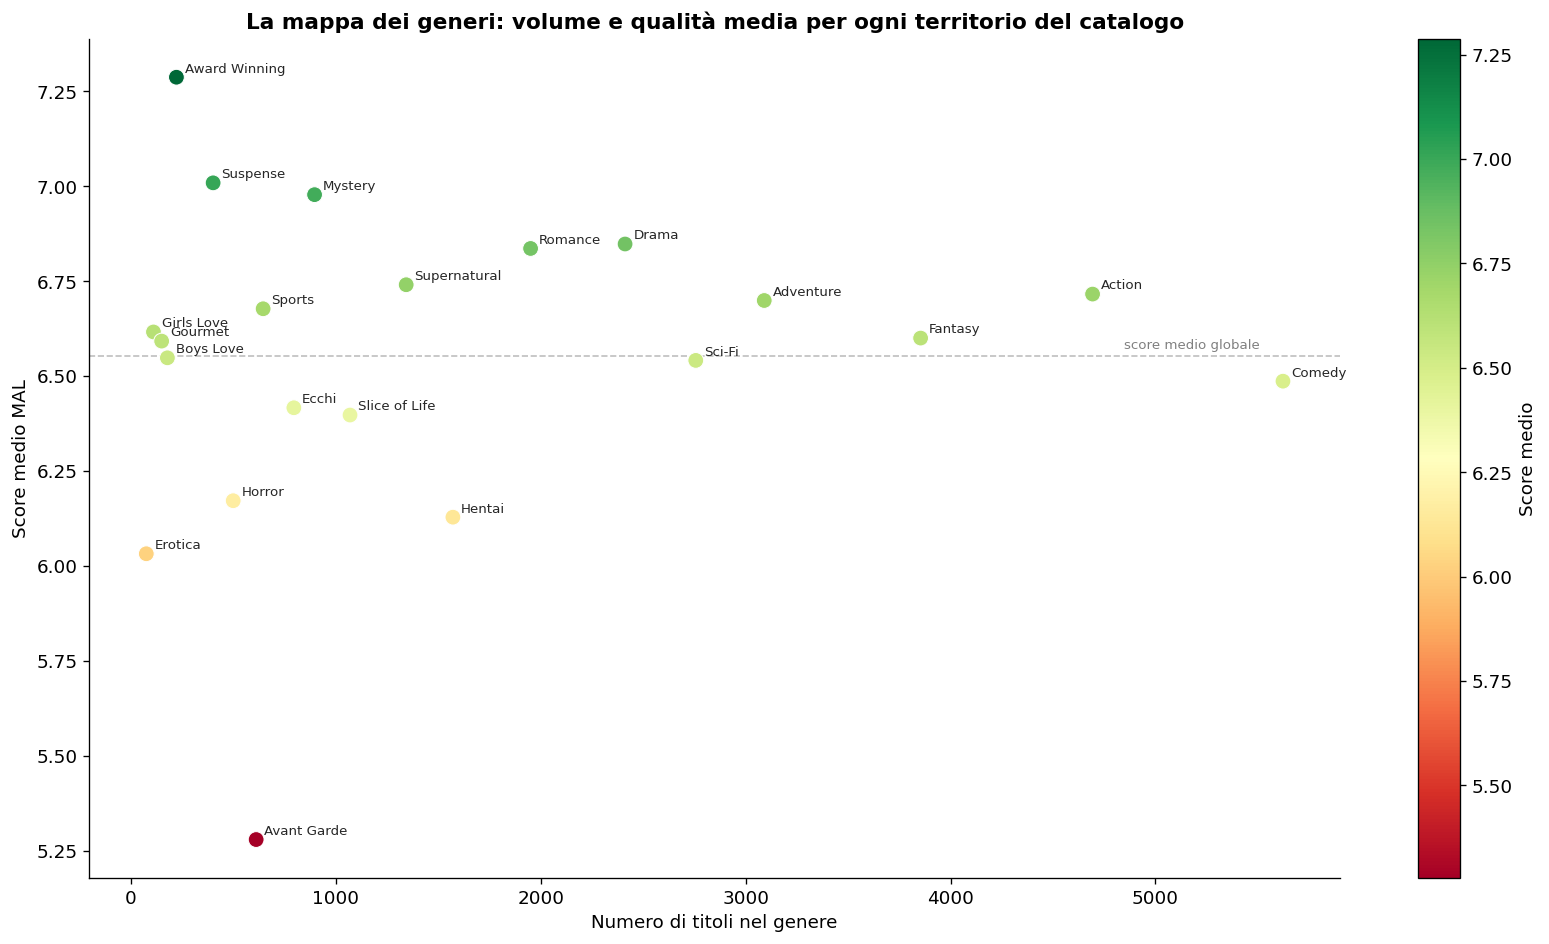

In [8]:
det_g = details.dropna(subset=['genres', 'score']).copy()
det_g['genre'] = det_g['genres'].str[2:-2].str.split("', '")
det_g = det_g.explode('genre')
det_g = det_g[det_g['genre'].str.strip() != '']

genre_stats = (
    det_g.groupby('genre')
    .agg(n_titoli=('mal_id', 'count'), score_medio=('score', 'mean'))
    .query('n_titoli >= 30')
    .sort_values('score_medio', ascending=False)
    .reset_index()
)

# Colora per score medio
norm  = plt.Normalize(genre_stats['score_medio'].min(), genre_stats['score_medio'].max())
colors = plt.cm.RdYlGn(norm(genre_stats['score_medio'].values))

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    genre_stats['n_titoli'],
    genre_stats['score_medio'],
    c=genre_stats['score_medio'],
    cmap='RdYlGn',
    s=90, edgecolors='white', linewidths=0.6, zorder=3
)

# Etichetta ogni genere
for _, row in genre_stats.iterrows():
    ax.annotate(
        row['genre'],
        (row['n_titoli'], row['score_medio']),
        textcoords='offset points', xytext=(5, 3),
        fontsize=8, alpha=0.85
    )

ax.axhline(genre_stats['score_medio'].mean(), color='grey', lw=1, ls='--', alpha=0.5)
ax.text(genre_stats['n_titoli'].max() * 0.98,
        genre_stats['score_medio'].mean() + 0.02,
        'score medio globale', ha='right', fontsize=8, color='grey')

ax.set_xlabel('Numero di titoli nel genere')
ax.set_ylabel('Score medio MAL')
ax.set_title('La mappa dei generi: volume e qualità media per ogni territorio del catalogo',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(scatter, ax=ax, label='Score medio')
plt.tight_layout()
plt.show()

Una volta capita la struttura del territorio, la domanda naturale diventa: quali sono i titoli migliori al suo interno? Due criteri diversi danno risposte diverse.

Il **punteggio medio** aggrega le valutazioni di migliaia di utenti: misura la qualità percepita dalla massa, ovvero quanti spettatori sono rimasti soddisfatti. I **favorites** misurano qualcosa di più viscerale — quante persone hanno deciso che quell'anime merita un posto speciale nel proprio profilo, al di là della valutazione numerica. Le due classifiche che seguono confrontano i top 10 per punteggio (con almeno 10.000 voti) e i top 10 per favorites. I titoli evidenziati in rosso compaiono in entrambe le liste.

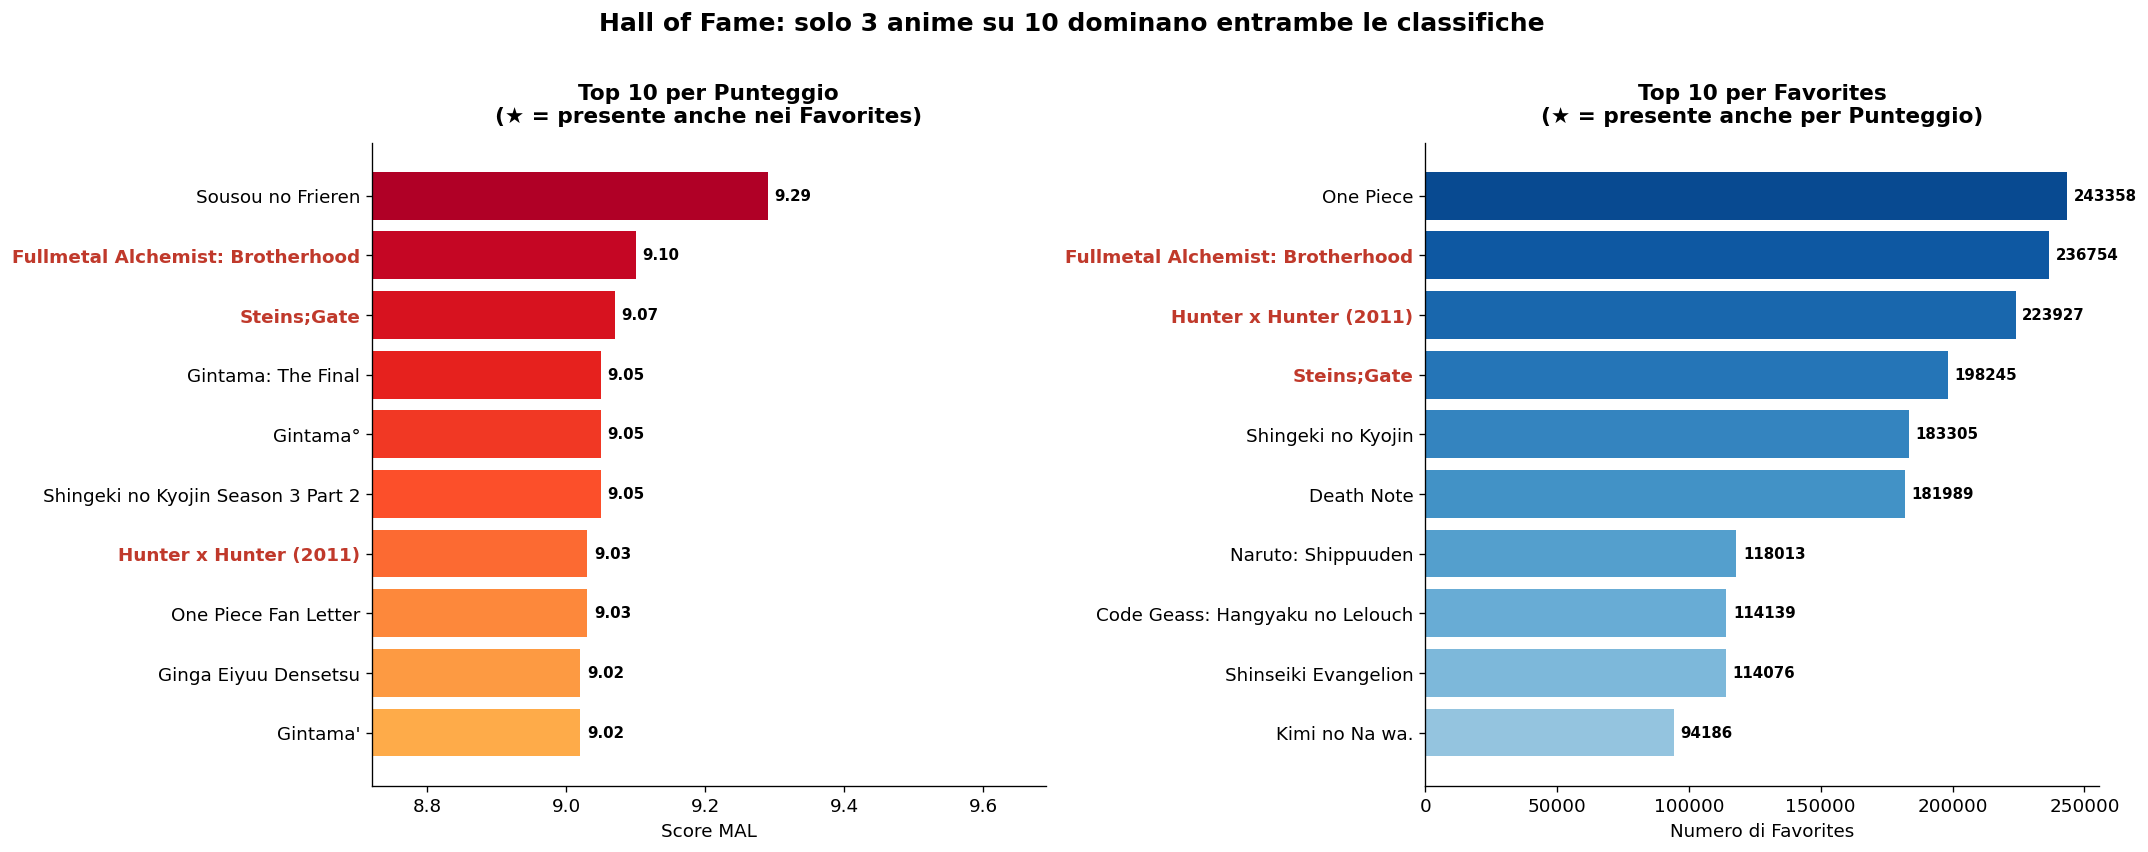

In [9]:
top_score = (
    details
    .query('scored_by >= 10000')
    .nlargest(10, 'score')
    [['title', 'score', 'favorites', 'year']]
    .reset_index(drop=True)
)

top_fav = (
    details
    .nlargest(10, 'favorites')
    [['title', 'favorites', 'score']]
    .reset_index(drop=True)
)

# Evidenzia i titoli in comune tra le due classifiche
in_both = set(top_score['title']) & set(top_fav['title'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette_score = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 10))
bars_s = axes[0].barh(top_score['title'][::-1], top_score['score'][::-1], color=palette_score)
axes[0].bar_label(bars_s, fmt='%.2f', padding=4, fontweight='bold', fontsize=9)
axes[0].set_xlabel('Score MAL')
axes[0].set_title('Top 10 per Punteggio\n(★ = presente anche nei Favorites)',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlim(top_score['score'].min() - 0.3, top_score['score'].max() + 0.4)
axes[0].spines[['top', 'right']].set_visible(False)
for label in axes[0].get_yticklabels():
    if label.get_text() in in_both:
        label.set_fontweight('bold')
        label.set_color('#c0392b')

palette_fav = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
bars_f = axes[1].barh(top_fav['title'][::-1], top_fav['favorites'][::-1], color=palette_fav)
axes[1].bar_label(bars_f, fmt='%d', padding=4, fontweight='bold', fontsize=9)
axes[1].set_xlabel('Numero di Favorites')
axes[1].set_title('Top 10 per Favorites\n(★ = presente anche per Punteggio)',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].spines[['top', 'right']].set_visible(False)
for label in axes[1].get_yticklabels():
    if label.get_text() in in_both:
        label.set_fontweight('bold')
        label.set_color('#c0392b')

n_overlap = len(in_both)
plt.suptitle(f'Hall of Fame: solo {n_overlap} anime su 10 dominano entrambe le classifiche',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


La mappa dei generi e la Hall of Fame insieme danno un primo orientamento completo: sai quali territori esistono, qual è la qualità media di ciascuno, e quali titoli rappresentano il meglio in assoluto.

I titoli che compaiono sia nella classifica per punteggio che in quella per favorites sono pochi — e questa divergenza è rilevante. Score e favorites misurano fenomeni distinti: il punteggio premia la coerenza qualitativa percepita da un pubblico ampio; i favorites misurano l'attaccamento emotivo, quante persone hanno sentito quell'anime come qualcosa di proprio.

Sapere dove si trovano i punti di riferimento è però solo il primo passo. Il vero problema della navigazione emerge subito dopo: hai visto i titoli al top — e adesso? Come si trova il prossimo anime che fa per te in un catalogo di quasi trentamila titoli?

---
## 2. Navigare per connessioni: le raccomandazioni del fandom

Il modo più naturale di navigare un catalogo enorme è partire da qualcosa che già conosci e amai, e muoversi verso ciò che gli assomiglia. È il principio alla base di qualsiasi motore di raccomandazione — ma MAL lo implementa in modo radicalmente diverso dagli algoritmi commerciali.

Su Netflix o Spotify, le raccomandazioni emergono da pattern statistici sul comportamento di milioni di utenti: se chi guarda X tende a guardare anche Y, il sistema li collega. Su MAL, le raccomandazioni sono scritte a mano dagli utenti, con una spiegazione esplicita del perché due anime sono simili — trama analoga, stesso autore, atmosfera simile, protagonisti con caratteristiche comuni. Quando molti utenti indipendenti raccomandano la stessa coppia, il segnale diventa robusto: è saggezza collettiva, non ottimizzazione di una metrica commerciale.

Il grafico che segue mostra, per un anime di partenza configurabile, quali titoli la community co-raccomanda più spesso. La barra più lunga indica il passo di navigazione con il consenso più alto — dove il fandom, aggregato, dice che dovresti andare dopo.

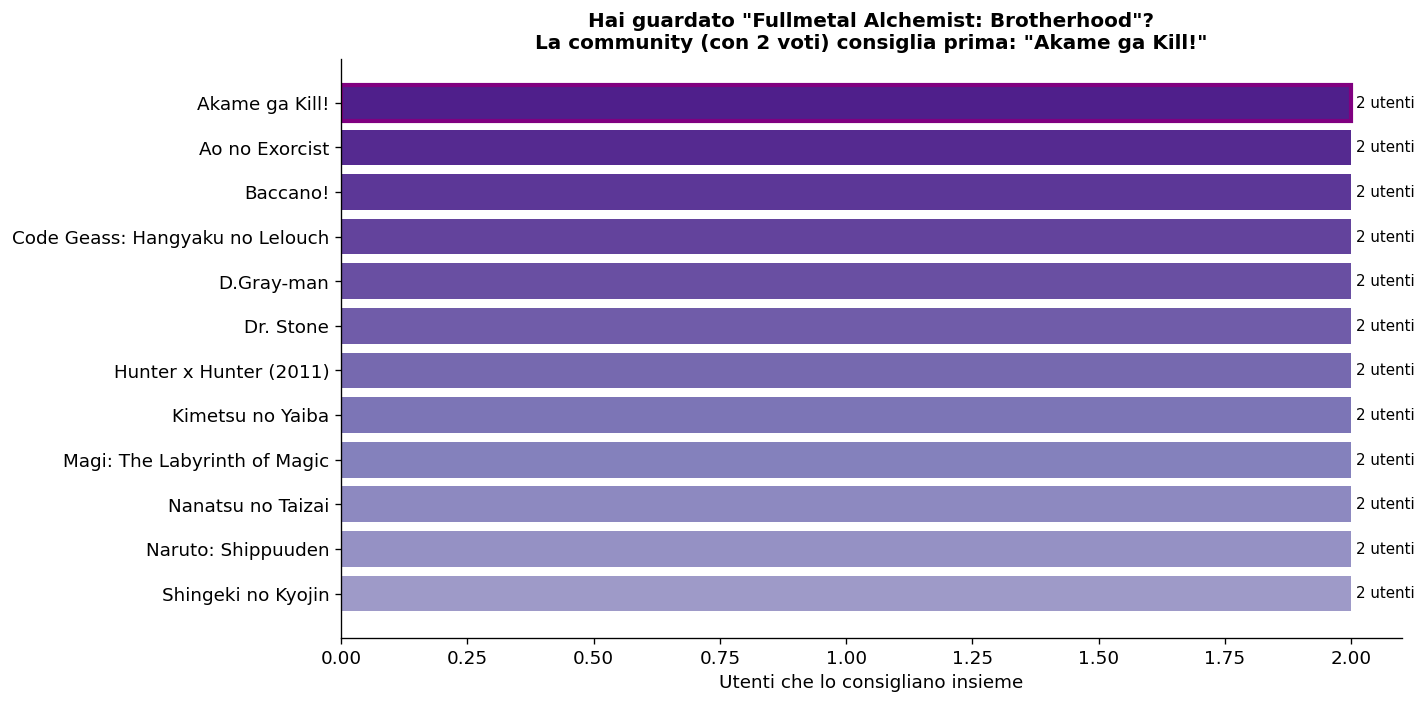

In [10]:
INPUT_ANIME = 'Fullmetal Alchemist: Brotherhood'  # <-- cambia qui

match = details[details['title'].str.contains(INPUT_ANIME, case=False, na=False)]

if match.empty:
    print(f'Nessun anime trovato per: {INPUT_ANIME!r}')
else:
    anime_id   = match.iloc[0]['mal_id']
    anime_name = match.iloc[0]['title']

    fwd    = recs.loc[recs['mal_id'] == anime_id, 'recommendation_mal_id']
    bwd    = recs.loc[recs['recommendation_mal_id'] == anime_id, 'mal_id']
    counts = pd.concat([fwd, bwd]).value_counts().head(12).rename('n_rec')

    rec_df = (
        details
        .loc[details['mal_id'].isin(counts.index), ['mal_id', 'title', 'score', 'year']]
        .set_index('mal_id')
        .assign(n_rec=counts)
        .dropna(subset=['n_rec'])
        .sort_values('n_rec', ascending=False)
    )

    top_rec   = rec_df.iloc[0]
    consensus = int(rec_df['n_rec'].iloc[0])

    fig, ax = plt.subplots(figsize=(12, 6))
    palette = plt.cm.Purples(np.linspace(0.5, 0.9, len(rec_df)))
    bars = ax.barh(rec_df['title'][::-1], rec_df['n_rec'][::-1], color=palette)
    ax.bar_label(bars, fmt='%d utenti', padding=3, fontsize=9)

    # Evidenzia il primo consiglio
    bars[-1].set_edgecolor('purple')
    bars[-1].set_linewidth(2.5)

    ax.set_xlabel('Utenti che lo consigliano insieme')
    ax.set_title(
        f'Hai guardato "{anime_name}"?\n'
        f'La community (con {consensus} voti) consiglia prima: "{top_rec["title"]}"',
        fontsize=12, fontweight='bold'
    )
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


La resistenza alla manipolazione di questo sistema è la sua forza principale come strumento di navigazione. Chi scrive una raccomandazione su MAL non ha incentivi commerciali: lo fa perché vuole che altri apprezzino qualcosa che ha amato. Il consenso che emerge — quanti utenti raccomandano indipendentemente la stessa coppia — misura la forza reale della connessione percepita tra i due titoli.

Per usarlo: cambia `INPUT_ANIME` con qualsiasi titolo che hai amato e il grafico mostra la mappa dei passi successivi suggeriti dal fandom. È uno strumento di navigazione personalizzato, costruito da chi ha già percorso quel tratto di catalogo prima di te.

C'è però un limite strutturale: le raccomandazioni funzionano bene per i titoli popolari, perché molti utenti li hanno visti e possono connetterli ad altri. Ma il catalogo contiene migliaia di anime che quasi nessuno ha ancora esplorato — e per questi, la rete di raccomandazioni è quasi vuota. Esistono capolavori che non compaiono in nessuna lista, non perché non valgano, ma perché non abbastanza persone li hanno ancora trovati.

---
## 3. Oltre la mappa conosciuta: i capolavori nascosti

Le raccomandazioni e le classifiche disegnano una mappa densa nella zona dei titoli popolari — ma quella mappa ha bordi bianchi. Gran parte del catalogo anime è territorio inesplorato: titoli prodotti in nicchie, distribuiti in mercati limitati, usciti in anni in cui la comunità internazionale era più piccola, o semplicemente mai finiti nel flusso delle conversazioni mainstream.

MAL permette di identificare questi titoli con precisione. Un anime con score ≥ 8.0 è — per definizione — considerato eccellente da chi lo ha visto: la media MAL si aggira intorno al 6.4, e superare l'8.0 richiede un consenso positivo significativo. La popolarità si misura con `scored_by` — quante persone hanno effettivamente valutato l'anime — che funziona indipendentemente dalla lunghezza della serie o dal suo stato (in corso o terminato). Un titolo con `scored_by` basso è davvero fuori dal radar, non semplicemente difficile da finire.

I criteri di selezione sono conservativi: score ≥ 8.0, scored_by tra 200 e 5.000. La soglia inferiore garantisce che il punteggio non sia il risultato di un campione troppo piccolo; quella superiore esclude i titoli già conosciuti dalla massa. Il risultato è una lista di destinazioni per chi ha già esaurito i percorsi più battuti.

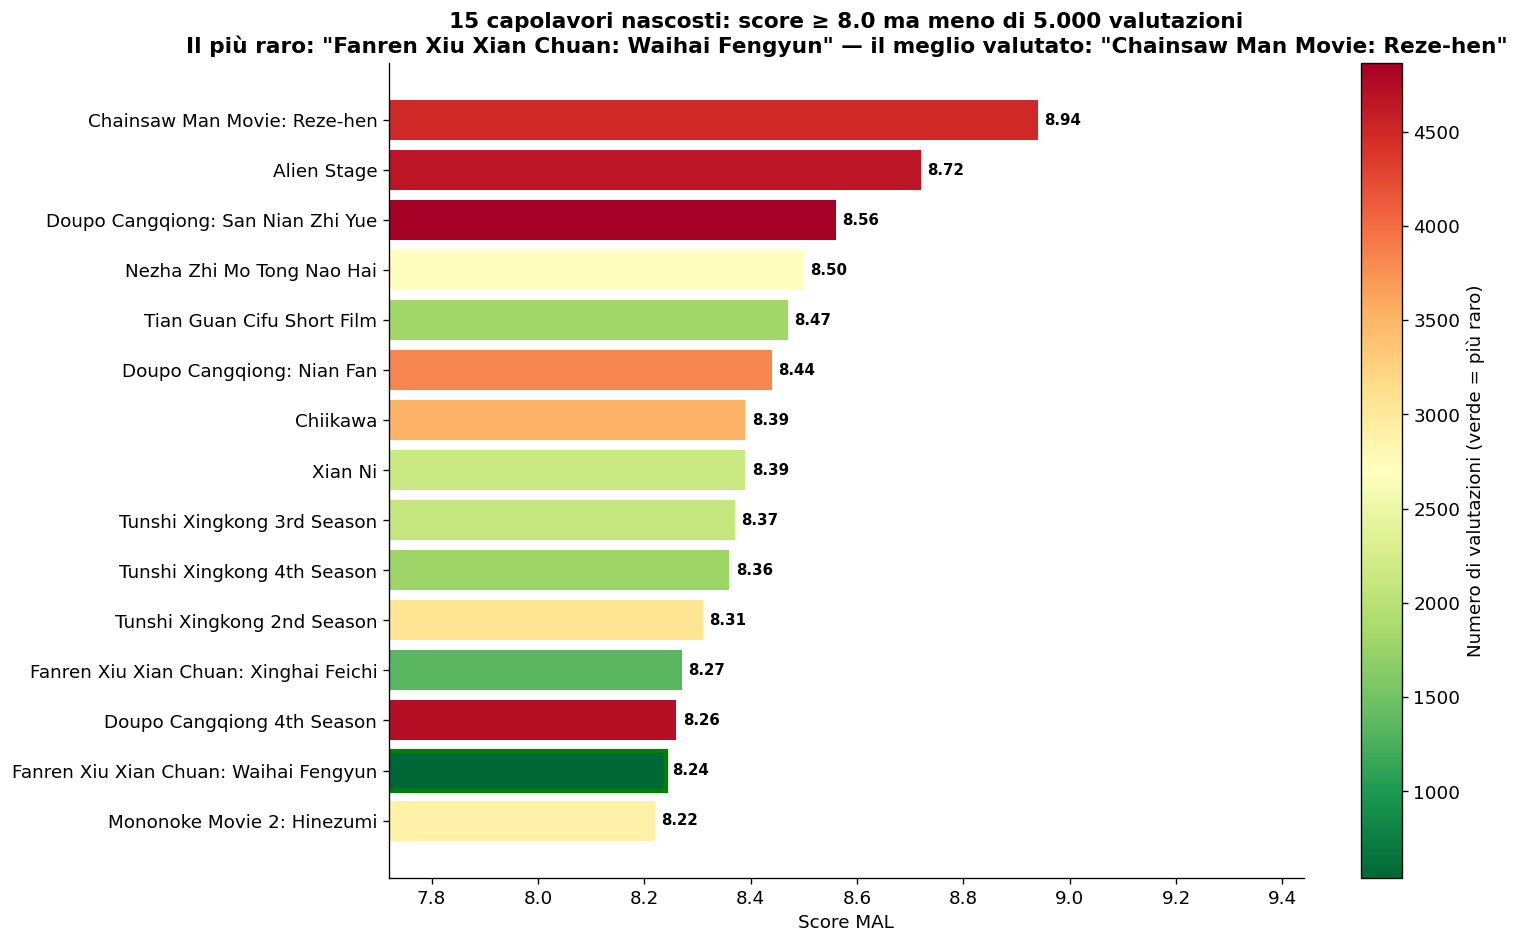

In [11]:
hidden = (
    details
    .query('score >= 8.0 and scored_by >= 200 and scored_by < 5000')
    .sort_values('score', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

norm   = plt.Normalize(hidden['scored_by'].min(), hidden['scored_by'].max())
colors = plt.cm.RdYlGn_r(norm(hidden['scored_by'].values[::-1]))

rarest  = hidden.loc[hidden['scored_by'].idxmin(), 'title']
best    = hidden.iloc[0]['title']
n_found = len(hidden)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(hidden['title'][::-1], hidden['score'][::-1], color=colors)
ax.bar_label(bars, fmt='%.2f', padding=4, fontweight='bold', fontsize=9)
ax.set_xlabel('Score MAL')
ax.set_xlim(hidden['score'].min() - 0.5, hidden['score'].max() + 0.5)
ax.set_title(
    f'{n_found} capolavori nascosti: score ≥ 8.0 ma meno di 5.000 valutazioni\n'
    f'Il più raro: "{rarest}" — il meglio valutato: "{best}"',
    fontsize=13, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)

rarest_idx = list(hidden['title'][::-1]).index(rarest)
bars[rarest_idx].set_edgecolor('green')
bars[rarest_idx].set_linewidth(2.5)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Numero di valutazioni (verde = più raro)')
plt.tight_layout()
plt.show()

La lista che emerge è una mappa del tesoro per chi vuole navigare oltre il mainstream. Ogni titolo rappresenta un'opera che ha convinto quasi chiunque l'abbia vista — ma che pochissime persone hanno ancora trovato. Il titolo con il minor numero di valutazioni, evidenziato in verde, è la destinazione più remota: il capolavoro più nascosto dell'intero dataset.

Usare `scored_by` invece dei completamenti risolve un problema strutturale importante: serie lunghe ancora in corso come One Piece o Naruto hanno pochissimi "completamenti" semplicemente perché finirle richiede anni — non perché siano sconosciute. `scored_by` cattura invece chiunque abbia guardato abbastanza episodi da esprimere una valutazione, indipendentemente dal formato o dalla lunghezza. Chi appare in questa lista è davvero fuori dal radar.

Finora abbiamo navigato il catalogo esistente — titoli già usciti, già valutati, già connessi. Ma ogni stagione il catalogo si espande: nuovi anime escono ogni tre mesi, e alcuni di essi potrebbero essere le prossime hidden gems prima ancora che qualcuno le scopra. Per intercettarli, serve capire la struttura temporale delle uscite.

---
## 4. Navigare nel tempo: il calendario stagionale delle uscite

Il catalogo anime non è statico: si rinnova ogni tre mesi, seguendo il ritmo delle stagioni giapponesi — Winter, Spring, Summer, Fall. Per un fan che vuole stare al passo, o che vuole intercettare un titolo prima che diventi popolare (e magari scoprire la prossima hidden gem in tempo reale), capire la struttura del calendario è uno strumento di navigazione essenziale.

La domanda è: la distribuzione dei generi tra le stagioni è casuale, o le case di produzione seguono una logica precisa? Se esistono pattern stabili — certi generi che si concentrano in certe stagioni — allora il calendario diventa prevedibile, e un fan può calibrare le aspettative stagione per stagione invece di scoprirlo ogni volta.

La heatmap che segue mostra, per ciascuna combinazione stagione/genere, quanti anime sono stati rilasciati storicamente. I rettangoli blu evidenziano la stagione dominante per i tre generi più prodotti in assoluto.

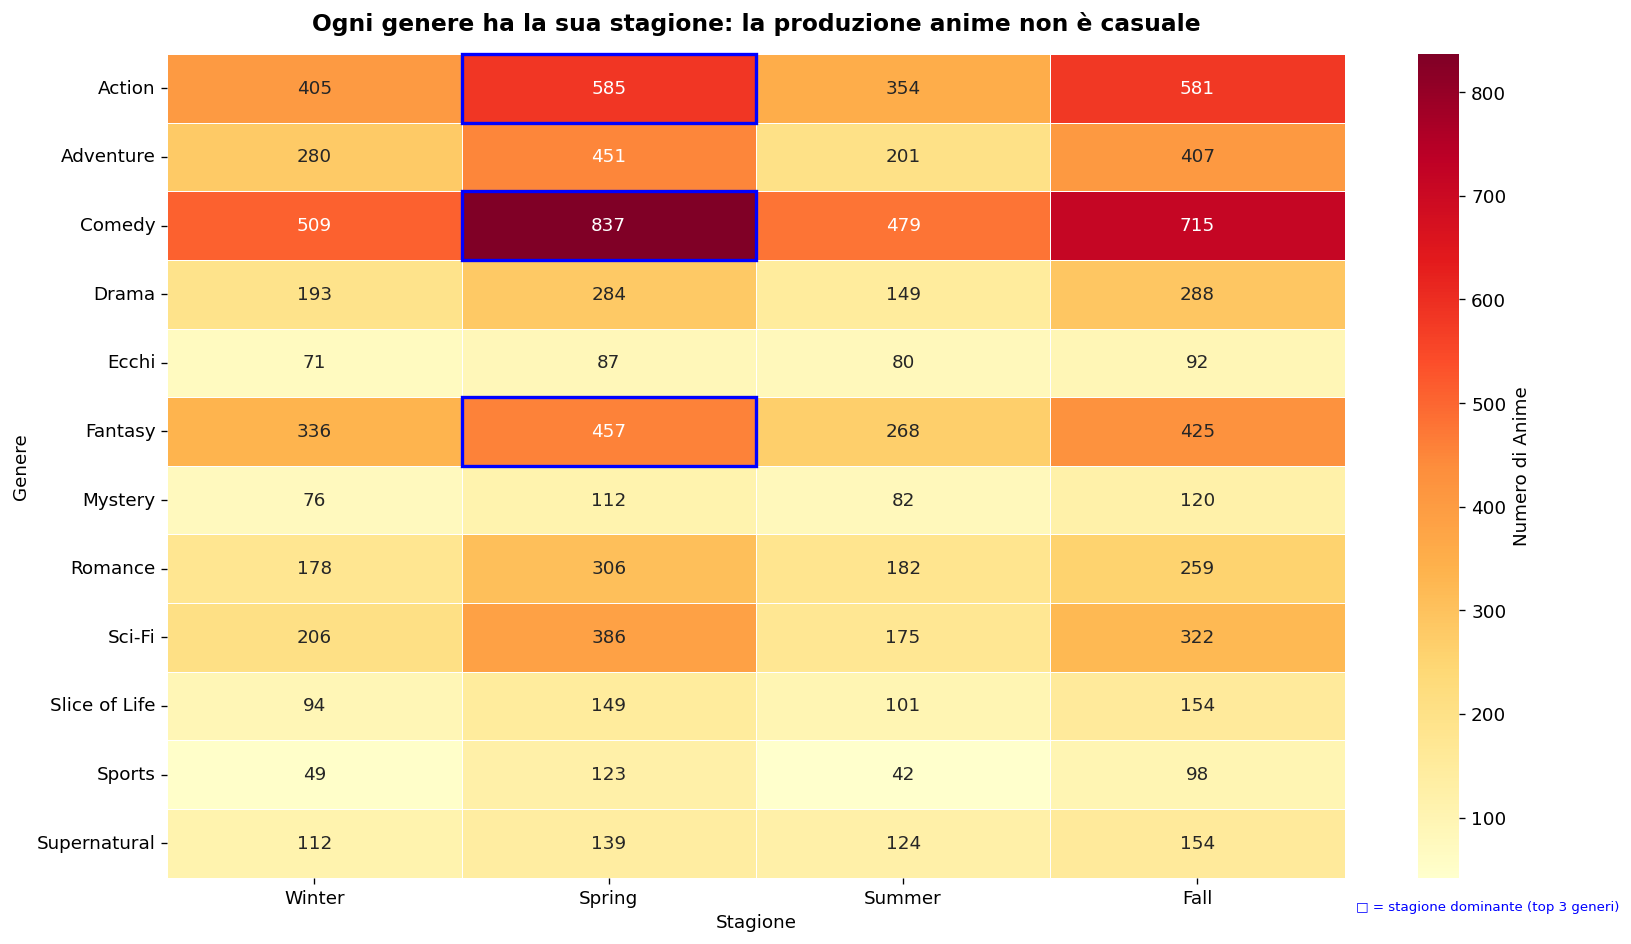

In [12]:
det_genres = details.dropna(subset=['season', 'genres']).copy()
det_genres['genre'] = det_genres['genres'].str[2:-2].str.split("', '")
det_genres = det_genres.explode('genre')
det_genres = det_genres[det_genres['genre'].str.strip() != '']

top_genres   = det_genres['genre'].value_counts().head(12).index
season_order = ['winter', 'spring', 'summer', 'fall']

pivot = (
    det_genres
    .query('genre in @top_genres')
    .groupby(['season', 'genre'])
    .size()
    .unstack(fill_value=0)
    .reindex([s for s in season_order if s in det_genres['season'].unique()])
)
pivot.index = pivot.index.str.capitalize()

# Stagione dominante per ogni genere
dominant_season = pivot.idxmax(axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot.T, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Numero di Anime'}
)
ax.set_title('Ogni genere ha la sua stagione: la produzione anime non è casuale',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Stagione')
ax.set_ylabel('Genere')

# Annota la stagione dominante per i top 3 generi
for genre in list(top_genres)[:3]:
    if genre in pivot.columns:
        row_idx = list(pivot.T.index).index(genre)
        col_idx = list(pivot.index).index(dominant_season[genre])
        ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1,
                     fill=False, edgecolor='blue', lw=2, clip_on=False))

ax.text(1.01, -0.04, '□ = stagione dominante (top 3 generi)',
        transform=ax.transAxes, fontsize=8, color='blue', ha='left')

plt.tight_layout()
plt.show()


La distribuzione non è uniforme — e questo è già di per sé un risultato di navigazione. Esistono generi che si concentrano chiaramente in certe stagioni, il che significa che le case di produzione non rilasciano i titoli a caso: ci sono strategie, tradizioni, e probabilmente decisioni competitive (evitare di competere con titoli simili nella stessa finestra stagionale).

Per un fan, questa mappa ha un'utilità pratica diretta: se segui principalmente un certo genere, sapere in quale stagione tende a concentrarsi ti permette di sapere quando tenere gli occhi aperti e quando aspettarti meno. Le stagioni "povere" per il tuo genere non sono una coincidenza — sono strutturali.

Vale anche la pena notare che il calendario riflette la struttura editoriale giapponese: manga e light novel seguono cicli di pubblicazione che condizionano i tempi di produzione degli anime. Il ritmo stagionale che vediamo è il risultato di una catena produttiva complessa — e conoscerlo significa navigare con cognizione di causa, non affidarsi al caso.

---
## Conclusione: quattro strumenti per orientarsi

Il problema del fandom moderno non è la mancanza di contenuto — è l'eccesso. Con quasi 29.000 titoli catalogati e centinaia di nuove uscite ogni anno, la sfida non è trovare anime da guardare: è trovare *quello giusto per te*, nel momento giusto.

Questo notebook ha proposto quattro strumenti di navigazione complementari, ciascuno utile in una fase diversa del percorso.

La **Hall of Fame** offre i punti di riferimento iniziali: i landmark del catalogo, differenziati tra qualità media e attaccamento emotivo. Le **raccomandazioni del fandom** costruiscono i percorsi tra quei landmark: conoscendo un titolo che ami, puoi muoverti verso ciò che gli assomiglia seguendo il consenso collettivo di chi ha già percorso quel tratto. Le **hidden gems** aprono il territorio inesplorato: capolavori che le classifiche e le raccomandazioni non raggiungono, ma che i dati di MAL permettono di identificare con precisione. Il **calendario stagionale**, infine, porta la navigazione nel tempo: capire quando e dove si concentrano certi generi significa sapere quando tenere gli occhi aperti per le prossime scoperte.

Nessuno di questi strumenti funziona da solo — è usandoli insieme che si costruisce un percorso di scoperta che va dai titoli universalmente riconosciuti fino alle opere che quasi nessuno ha ancora trovato.

| Strumento di navigazione | A cosa serve |
|---|---|
| Hall of Fame | Trovare i punti di riferimento — i landmark del catalogo |
| Raccomandazioni | Muoversi per connessioni — "ho amato X, cosa guardo dopo?" |
| Hidden Gems | Esplorare oltre il mainstream — capolavori fuori dai radar |
| Calendario stagionale | Navigare nel tempo — sapere quando cercare cosa |